#########    All "our" in the following code refers to Joint Cabernet.

In [ ]:
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
import anndata as ad
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy.stats import gaussian_kde
import datetime

In [ ]:
# "indir" is a custom input path, and "outdir" is a custom output path.
# indir=""
# outdir=""

In [ ]:
from matplotlib.font_manager import fontManager, FontProperties
font_path =f"{indir}/arial.ttf"
fontManager.addfont(font_path)
font_prop = FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()

In [ ]:
RNA_origin="our"

# get the RNA by sublass df
with open("../../../../input/01-youth/subclass_order_for_integration_with_zeng.txt", "rt") as f:
    subclass_list=f.read().split("\n")[:-1]
subclass_list=[i for i in subclass_list if "NN" not in i]

df_RNA=pd.read_csv(f"{indir}/02-{RNA_origin}_subclass_mean_dat_final.csv",index_col=0).T.loc[subclass_list,:]

max_threshold_=0.2
cv_threshold_=0.5
df_RNA_selected=df_RNA.loc[subclass_list,:]
df_RNA_selected=df_RNA_selected.loc[subclass_list,
    (df_RNA_selected.max(axis=0)>max_threshold_) &
    (df_RNA_selected.apply(lambda col: col.std() / col.mean(), axis=0)>cv_threshold_)
            ]

/tmp/ipykernel_18779/1738856184.py:15: RuntimeWarning: invalid value encountered in scalar divide
  (df_RNA_selected.apply(lambda col: col.std() / col.mean(), axis=0)>cv_threshold_)


In [ ]:
modification="5hmCG"
state="hyper"

df_frac_segment_subclass=dict()
df_frac_segment_subclass["5hmCG"]=ad.read_h5ad(f"{indir}/5hmC_merged_allc_with_{modification[:-1]}_segment.h5ad").to_df().iloc[:len(subclass_list),:]
# df_frac_segment_subclass["total5mCG"]=ad.read_h5ad(f"{indir}/5mC_merged_allc_with_{modification[:-1]}_segment.h5ad").to_df().iloc[:len(subclass_list),:]
df_frac_segment_subclass["5hmCG"].index=df_RNA.index
# df_frac_segment_subclass["total5mCG"].index=df_RNA.index
# df_frac_segment_subclass["true5mCG"]=df_frac_segment_subclass["total5mCG"]-df_frac_segment_subclass["5hmCG"]
# df_frac_segment_subclass["true5mCG"].clip(lower=0, inplace=True)

DMR_states_df=ad.read_h5ad(f"{indir}/{modification}_DMR_states_neuron_1vsOthers.h5ad").to_df()

if state == "hyper":
    segment_differential_states=(DMR_states_df==1).sum(axis=0)
elif state == "hypo":
    segment_differential_states=(DMR_states_df==-1).sum(axis=0)
elif state == "all":
    segment_differential_states=(DMR_states_df.abs()==1).sum(axis=0)

differential_segments=segment_differential_states[segment_differential_states>0].index


In [10]:
# import standard python libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

import cooltools
import cooler

import datetime

from matplotlib.colors import LogNorm

In [ ]:
with open("../../../../input/01-youth/subclass_order_for_integration_with_zeng.txt", "rt") as f:
    subclass_list=f.read().split("\n")[:-1]
subclass_list=[i for i in subclass_list if "NN" not in i]

csv_path = "../../../../input/01-youth/subclass_our_liu.csv"
df = pd.read_csv(csv_path, sep=',')
df = df.iloc[:len(subclass_list),:]

In [ ]:
df_chrom30k_step10k = ad.read_h5ad(f'{indir}/5hmCG_frac_chrom30k_step10k_by_subclass.h5ad').to_df().iloc[:len(subclass_list),]
df_chrom30k_step10k

chrom30k_step10k,chr1_0_30000,chr1_10000_40000,chr1_20000_50000,chr1_30000_60000,chr1_40000_70000,chr1_50000_80000,chr1_60000_90000,chr1_70000_100000,chr1_80000_110000,chr1_90000_120000,...,chr19_61340000_61370000,chr19_61350000_61380000,chr19_61360000_61390000,chr19_61370000_61400000,chr19_61380000_61410000,chr19_61390000_61420000,chr19_61400000_61430000,chr19_61410000_61431566,chr19_61420000_61431566,chr19_61430000_61431566
cell,,,,,,,,,,,,,,,,,,,,,
5hmC_L2.3.IT.CTX.Glut.Merge.allc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5hmC_L4.5.IT.CTX.Glut.Merge.allc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5hmC_L5.IT.CTX.Glut.Merge.allc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5hmC_L2.3.IT.RSP.Glut.Merge.allc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5hmC_L4.RSP-ACA.Glut.Merge.allc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5hmC_L5.ET.CTX.Glut.Merge.allc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5hmC_SUB-ProS.Glut.Merge.allc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5hmC_CA1-ProS.Glut.Merge.allc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5hmC_CA3.Glut.Merge.allc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#chrom_=genes_df[genes_df["gene_id"]==x].loc[:,"chromosome"].iloc[0]
print(f"initialization started at  {datetime.datetime.now()}")
resolution_=10_000

mcool_file={subclass_liu : f'{indir}/{subclass_liu}.Q.10K.mcool'
           for subclass_liu in df['subclass_liu']}
clr={subclass_liu : cooler.Cooler(f'{mcool_file[subclass_liu]}::resolutions/{resolution_}') for subclass_liu in df['subclass_liu']}

matrixes_=dict()
for chrom_ in tqdm(['chr'+str(i) for i in [2,]]):
    matrixes_[chrom_]=[
               clr[subclass_liu].matrix(balance=True).fetch(chrom_)[:] 
                     for subclass_liu in df['subclass_liu']
           ] 
           
print(f"initialization finished at {datetime.datetime.now()}")

initialization started at  2025-01-18 22:28:35.268979


  0%|          | 0/1 [00:00<?, ?it/s]

initialization finished at 2025-01-18 22:30:03.195176


In [ ]:
from matplotlib.font_manager import fontManager, FontProperties
font_path =f"{indir}/arial.ttf"
fontManager.addfont(font_path)
font_prop = FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['font.size']=7

In [15]:
from scipy.stats import linregress

In [16]:
colors_={i.split(' : ')[0] : i.split(' : ')[1] for i in """CA1-ProS Glut : #f173ac 
SUB-ProS Glut : #da765b 
Oligo NN : #3498db 
L2/3 IT RSP Glut : #89288F 
DG Glut : #F47D2B 
Astro-TE NN : #65c294 
CA3 Glut : #8A9FD1 
Sncg Gaba : #C06CAB 
OPC NN : #2585a6 
L2/3 IT CTX Glut : #90D5E4 
L4 RSP-ACA Glut : #ed1941 
L5 ET CTX Glut : #b2d235 
L6 CT CTX Glut : #3BBCA8 
Pvalb Gaba : #FEE500 
L5 NP CTX Glut : #61599d 
L5 IT CTX Glut : #33a3dc 
OB-STR-CTX Inh IMN : #DEA0FD 
Sst Gaba : #FFB300 
ACB-BST-FS D1 Gaba : #007947 
Microglia NN : #FF6800 
OB-in Frmd7 Gaba : #3283FE 
Lamp5 Gaba : #00a6ac 
L4/5 IT CTX Glut : #00538A 
CLA-EPd-CTX Car3 Glut : #8552a1 
STR D1 Gaba : #FF8E00 
OB-out Frmd7 Gaba : #F4C800 
OB Eomes Ms4a15 Glut : #2ecc71 
OB Dopa-Gaba : #f1c40f 
OEC NN : #9b59b6 
STR D2 Gaba : #11776CFF""".split(' \n')}

In [17]:
df['merged_allc']=df['subclass_our'].apply(lambda x : '5hmC_'+x.replace('/','.').replace(' ','.')+'.Merge.allc')
id_dict=dict()
for _, row_ in df.iterrows():
    id_dict[row_['merged_allc']]=row_['subclass_our']

In [ ]:
df_60kb=ad.read_h5ad(f'{indir}/5hmCG_frac_60kb_bin_merged_allc.h5ad').to_df()
df_60kb.index=pd.Series(df_60kb.index).apply(lambda x : x if 'NN' in x else id_dict[x])
df_60kb=df_60kb.loc[subclass_list,:]
df_60kb

segment,chr2_19690000_19750000,chr2_19900000_20820000
cell,,
L2/3 IT CTX Glut,0.244207,0.284654
L4/5 IT CTX Glut,0.240407,0.294434
L5 IT CTX Glut,0.285652,0.346429
L2/3 IT RSP Glut,0.278888,0.310928
L4 RSP-ACA Glut,0.320478,0.363027
L5 ET CTX Glut,0.287193,0.314816
SUB-ProS Glut,0.272367,0.293975
CA1-ProS Glut,0.239419,0.269433
CA3 Glut,0.263223,0.268562


In [21]:
gene_id_='ENSMUSG00000036617.16'

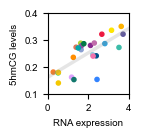

In [ ]:
a=df_60kb[['chr2_19690000_19750000']]
b=df_RNA_selected[[gene_id_]]
a.index=b.index
a.columns=['5hmCG']
b.columns=['RNA']
c=pd.concat([a,b], axis=1)
plt.figure(figsize=(36/25.4,36/25.4))
slope, intercept, r_value, p_value, std_err = linregress(c['RNA'],c['5hmCG'])
#line_x=np.array([np.min(c['RNA']), np.max(c['RNA'])])
line_x=np.array([0,4])
plt.plot(line_x, slope*line_x + intercept, color='grey',alpha=0.2, linewidth=2.5)

plt.scatter(x=c['RNA'],y=c['5hmCG'],c=pd.Series(c.index).apply(lambda x : colors_[x]).to_list(), s=9)

plt.xlim((0,4));plt.ylim((0.1,0.4));
plt.xlabel('RNA expression');plt.ylabel('5hmCG levels')
ax = plt.gca()  # 获取当前轴对象
ax.set_aspect((4-0)/(0.4-0.1))
plt.tight_layout()
plt.savefig('../../../../output/01-youth/06-m3C_supplementary_figures/03-scatter_RNA_5hmCG_PCC.pdf')
plt.savefig('../../../../output/01-youth/06-m3C_supplementary_figures/03-scatter_RNA_5hmCG_PCC.png', dpi=600)

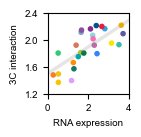

In [ ]:
e=pd.DataFrame([np.nansum(matrixes_[chrom_][subclass_index]\
                       [1969: 1975, 1990:2082]) for subclass_index in range(len(subclass_list))])
b=df_RNA_selected[[gene_id_]]
e.index=b.index
e.columns=['3C interaction']
b.columns=['RNA expression']
f=pd.concat([e,b], axis=1)
plt.figure(figsize=(36/25.4,36/25.4))
slope, intercept, r_value, p_value, std_err = linregress(f['RNA expression'],f['3C interaction'])
#line_x=np.array([np.min(c['RNA']), np.max(c['RNA'])])
line_x=np.array([0,4])
plt.plot(line_x, slope*line_x + intercept, color='grey',alpha=0.2, linewidth=2.5)

plt.scatter(x=f['RNA expression'],y=f['3C interaction'],c=pd.Series(f.index).apply(lambda x : colors_[x]).to_list(), s=9)

plt.xlim((0,4));plt.ylim((1.2,2.4));plt.yticks([1.2,1.6,2.0,2.4])
plt.xlabel('RNA expression');plt.ylabel('3C interaction')
ax = plt.gca()  # 获取当前轴对象
ax.set_aspect((4-0)/(2.4-1.2))
plt.tight_layout()
plt.savefig('../../../../output/01-youth/06-m3C_supplementary_figures/03-scatter_RNA_3C_PCC.pdf')
plt.savefig('../../../../output/01-youth/06-m3C_supplementary_figures/03-scatter_RNA_3C_PCC.png', dpi=600)
